# Sonrisa de Volatilidad: Machine Learning vs Black-Scholes

**Objetivo:** Contrastar la capacidad predictiva de un modelo de Machine Learning frente a la teoría clásica de Black-Scholes para modelar la Volatilidad Implícita de opciones financieras sobre Microsoft (MSFT).

**Hipótesis:** El mercado real presenta asimetrías (la "sonrisa") que Black-Scholes no puede capturar con volatilidad constante, pero que un algoritmo de ML sí puede aprender.

---
**Estructura del notebook:**
1. Extracción de datos en vivo (yfinance)
2. Preprocesamiento y construcción de variables
3. Modelo ML: Random Forest sobre Volatilidad Implícita
4. Modelo analítico: Fórmula de Black-Scholes
5. Validación visual: Gráfico de la Sonrisa
6. Validación numérica: MAE sobre precios
7. Análisis econométrico: Modelo ADL de volatilidad histórica

##Importación de Librerías

In [1]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

import yfinance as yf

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

from scipy.optimize import brentq

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

#Configuración general de gráficos
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

## Extracción de Datos

Se extraen:
- **Precio spot** actual de MSFT ($S_t$)
- **Cadena de opciones Call** para la fecha de vencimiento más cercana entre 30 y 90 días
- **Precio histórico** de MSFT (últimos 2 años) para el modelo ADL

In [2]:
#Descargar datos del subyacente
ticker = yf.Ticker('MSFT')

#Precio spot actual
hist_spot = ticker.history(period='1d')
S0 = hist_spot['Close'].iloc[-1]
print(f' Precio spot MSFT ($S_0$): ${S0:.2f}')

#vencimiento entre 30 y 90 días
from datetime import datetime, timedelta

hoy = datetime.today()
vencimientos = ticker.options  # lista de strings 'YYYY-MM-DD'

#Filtrar vencimientos en la ventana [30, 90] días
opciones_validas = [
    v for v in vencimientos
    if 30 <= (datetime.strptime(v, '%Y-%m-%d') - hoy).days <= 90
]

#Si no hay en esa ventana, tomar el más cercano disponible
if not opciones_validas:
    opciones_validas = [vencimientos[1] if len(vencimientos) > 1 else vencimientos[0]]

fecha_exp = opciones_validas[0]
T = (datetime.strptime(fecha_exp, '%Y-%m-%d') - hoy).days / 365
print(f' Fecha de vencimiento seleccionada: {fecha_exp}  (T = {T:.4f} años)')

#Extraer cadena de opciones Call
chain = ticker.option_chain(fecha_exp)
calls_raw = chain.calls.copy()

print(f'\n Contratos Call disponibles: {len(calls_raw)}')
print(f'Columnas disponibles: {list(calls_raw.columns)}')
calls_raw.head(3)

 Precio spot MSFT ($S_0$): $365.46
 Fecha de vencimiento seleccionada: 2026-07-31  (T = 0.0986 años)

 Contratos Call disponibles: 54
Columnas disponibles: ['contractSymbol', 'lastTradeDate', 'strike', 'lastPrice', 'bid', 'ask', 'change', 'percentChange', 'volume', 'openInterest', 'impliedVolatility', 'inTheMoney', 'contractSize', 'currency']


,contractSymbol,lastTradeDate,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,impliedVolatility,inTheMoney,contractSize,currency
0,MSFT260731C00270000,2026-06-22 17:55:47+00:00,270.0,98.83,95.40,99.15,-2.639999,-2.601754,1,3,0.622562,True,REGULAR,USD
1,MSFT260731C00280000,2026-06-24 14:00:03+00:00,280.0,96.84,85.70,89.30,0.839996,0.874996,1,12,0.577275,True,REGULAR,USD
2,MSFT260731C00290000,2026-06-24 14:36:25+00:00,290.0,85.61,76.05,79.60,-6.089996,-6.641218,1,19,0.536137,True,REGULAR,USD


## Preprocesamiento y Construcción de Variables

Se limpian los datos y se construyen las variables clave:
- **Moneyness** = $K / S_t$ (coordenada geométrica del contrato)
- **Mid-Price** = promedio de bid y ask (precio real de mercado)
- Se eliminan contratos sin liquidez (bid=0, IV=0)

In [3]:
#Parámetros del modelo
r = 0.045      # Tasa libre de riesgo (Fed Funds aproximado)
q = 0.0075     # Dividend yield de MSFT (~0.75%)

#Limpieza de la cadena de opciones
df = calls_raw[[
    'strike', 'bid', 'ask', 'lastPrice',
    'impliedVolatility', 'volume', 'openInterest'
]].copy()

#Calcular Mid-Price (precio real de referencia)
df['midPrice'] = (df['bid'] + df['ask']) / 2

#Filtrar contratos sin liquidez real
df = df[
    (df['bid'] > 0) &
    (df['impliedVolatility'] > 0.01) &
    (df['impliedVolatility'] < 3.0) &    # eliminar valores extremos
    (df['volume'] > 0)
].reset_index(drop=True)

#Variables de entrada para ML
df['Moneyness'] = df['strike'] / S0          # K/S_t
df['T'] = T                                   # Tiempo a vencimiento (constante para este cross-section)
df['log_Moneyness'] = np.log(df['Moneyness']) # log(K/S) — más simétrico

#Variable objetivo
df['IV_mercado'] = df['impliedVolatility']

print(f'Contratos útiles tras filtrado: {len(df)}')
print(f'Moneyness rango: [{df.Moneyness.min():.3f}, {df.Moneyness.max():.3f}]')
print(f'IV mercado rango: [{df.IV_mercado.min():.2%}, {df.IV_mercado.max():.2%}]')
print()
df[['strike', 'Moneyness', 'log_Moneyness', 'midPrice', 'IV_mercado']].head(8)

Contratos útiles tras filtrado: 53
Moneyness rango: [0.739, 1.532]
IV mercado rango: [43.05%, 62.26%]



,strike,Moneyness,log_Moneyness,midPrice,IV_mercado
0,270.0,0.738795,-0.302735,97.275,0.622562
1,280.0,0.766158,-0.266367,87.500,0.577275
2,290.0,0.793521,-0.231276,77.825,0.536137
3,300.0,0.820883,-0.197374,68.350,0.501836
4,305.0,0.834565,-0.180845,63.900,0.565068
5,310.0,0.848246,-0.164585,59.575,0.549931
6,315.0,0.861927,-0.148584,55.175,0.534490
7,320.0,0.875609,-0.132836,50.800,0.520085


## Modelo A: Random Forest para Volatilidad Implícita

**Variables de entrada:** Moneyness ($K/S_t$), log-Moneyness, $T$  
**Variable objetivo:** $\sigma_{IV}$ (Volatilidad Implícita del mercado)  

El modelo aprende la **forma geométrica de la sonrisa** directamente de los datos de mercado.

In [4]:
#Features y target
features = ['Moneyness', 'log_Moneyness', 'T']
target = 'IV_mercado'

X = df[features].values
y = df[target].values

#Train / Test split
# Usamos 80/20; en opciones tiene sentido ordenar por strike para no mezclar
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#Entrenar Random Forest
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=6,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

#Predecir sobre TODO el dataset (para graficar la curva completa)
df['IV_ML'] = rf.predict(X)

#Métricas en test
y_pred_test = rf.predict(X_test)
mae_iv = mean_absolute_error(y_test, y_pred_test)
r2_iv = r2_score(y_test, y_pred_test)

print(' Desempeño del Random Forest (IV) ')
print(f'   MAE  ($\sigma_IV$): {mae_iv:.4f}  ({mae_iv*100:.2f} puntos porcentuales)')
print(f'   R²         : {r2_iv:.4f}')
print()

#Importancia de variables
feat_imp = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
print('Importancia de variables:')
for f, v in feat_imp.items():
    print(f'   {f:20s}: {v:.4f}')

 Desempeño del Random Forest (IV) 
   MAE  ($\sigma_IV$): 0.0129  (1.29 puntos porcentuales)
   R²         : 0.8037

Importancia de variables:
   log_Moneyness       : 0.5289
   Moneyness           : 0.4711
   T                   : 0.0000


## Modelo B: Fórmula de Black-Scholes con Dividendos (Merton, 1973)

La fórmula de Black-Scholes para una opción Call europea con dividendos continuos ($q$) es:

$$C = S_t e^{-qT} N(d_1) - K e^{-rT} N(d_2)$$

donde:
$$d_1 = \frac{\ln(S_t/K) + (r - q + \sigma^2/2)T}{\sigma\sqrt{T}}, \quad d_2 = d_1 - \sigma\sqrt{T}$$

Se usará la **IV predicha por el ML** como input $\sigma$ para obtener el **Precio Teórico BS**.

In [ ]:
import scipy.stats as stats
from scipy.stats import norm

def black_scholes_call(S, K, T, r, q, sigma):

    """
    Precio de una opción Call europea con dividendos continuos.
    
    Parámetros
    ----------
    S     : Precio spot del subyacente
    K     : Strike price
    T     : Tiempo a vencimiento (en años)
    r     : Tasa libre de riesgo (continua)
    q     : Dividend yield continuo
    sigma : Volatilidad implícita
    
    Retorna
    -------
    precio : float, precio teórico de la call
    """

    if T <= 0 or sigma <= 0:
        return max(S * np.exp(-q*T) - K * np.exp(-r*T), 0)
    
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    
    precio = S * np.exp(-q * T) * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    return precio


#Aplicar BS con σ_ML (el motor predictivo alimenta la fórmula)
df['Precio_BS_ML'] = df.apply(
    lambda row: black_scholes_call(
        S=S0, K=row['strike'], T=T, r=r, q=q, sigma=row['IV_ML']
    ), axis=1
)

#También calcular BS con IV constante (benchmark naive)
sigma_constante = df['IV_mercado'].median() #valor constante de volatilidad com el valor medio actual del mercado
df['Precio_BS_Plano'] = df.apply(
    lambda row: black_scholes_call(
        S=S0, K=row['strike'], T=T, r=r, q=q, sigma=sigma_constante
    ), axis=1
)

print('Precios teóricos calculados.')
print(f' $\sigma$ constante (benchmark naive): {sigma_constante:.2%}')
print()
df[['strike', 'midPrice', 'IV_mercado', 'IV_ML', 'Precio_BS_ML', 'Precio_BS_Plano']].head(8)

ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

In [ ]:
#Filtramos el DataFrame buscando duplicados en la columna 'IV_ML'
#El parámetro keep=False asegura que nos muestre TODAS las filas que comparten el mismo valor.
filas_iguales = df[df.duplicated(subset=['IV_ML'], keep=False)]

#Ordenamos los resultados por la volatilidad predicha y luego por el Strike
filas_iguales = filas_iguales.sort_values(by=['IV_ML', 'strike'])

#Imprimimos solo las columnas relevantes para analizar el fenómeno
print("Contratos donde el Machine Learning predijo exactamente la misma volatilidad:")
print(filas_iguales[['strike', 'log_Moneyness', 'IV_mercado', 'IV_ML', 'Precio_BS_ML']])

Contratos donde el Machine Learning predijo exactamente la misma volatilidad:
---------------------------------------------------------------------------
    strike  log_Moneyness  IV_mercado     IV_ML  Precio_BS_ML
36   395.0       0.010843    0.325416  0.340620     14.588996
37   400.0       0.023422    0.325721  0.340620     12.465365
38   405.0       0.035845    0.325202  0.340620     10.576677
39   410.0       0.048115    0.326362  0.340620      8.911574
40   415.0       0.060236    0.327460  0.340620      7.456330
41   420.0       0.072212    0.326270  0.340620      6.195457
42   425.0       0.084047    0.328376  0.340620      5.112320
43   430.0       0.095743    0.332221  0.340620      4.189711
34   385.0      -0.014799    0.342811  0.340694     19.574737
35   390.0      -0.001896    0.328315  0.340694     16.959453
82   700.0       0.583038    0.673831  0.651980      0.045309
83   720.0       0.611209    0.713870  0.651980      0.027559
0    215.0      -0.597404    1.003911  0

## Validación Visual: La Sonrisa de Volatilidad

Se grafican tres curvas sobre el mismo eje Strike vs. Volatilidad:
1. **Puntos reales del mercado** (scatter)
2. **Curva predicha por ML** (línea suave)
3. **Línea plana de BS** (benchmark naive)

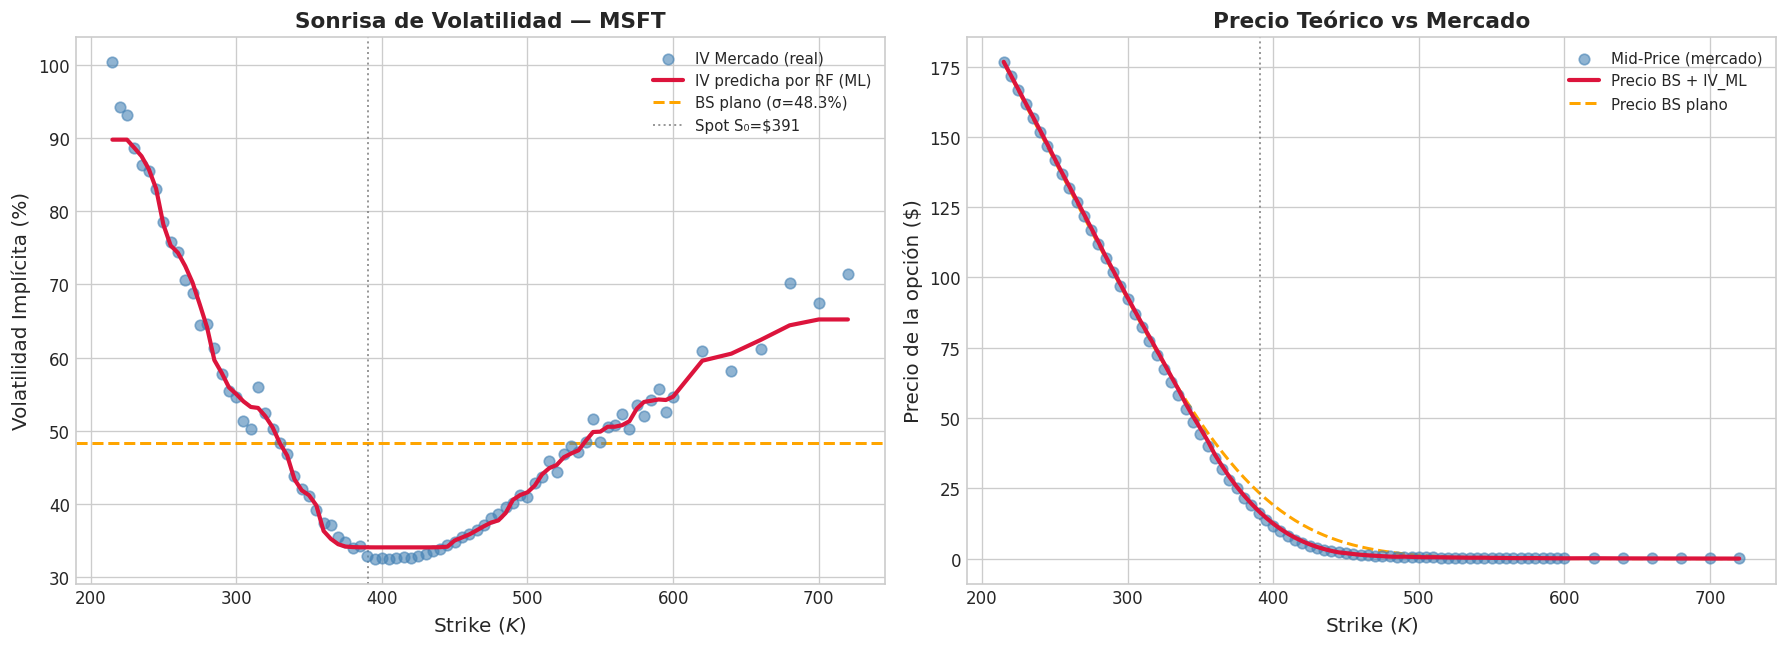

Gráfico guardado como sonrisa_volatilidad.png


In [ ]:
df_plot = df.sort_values('strike')

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

#Panel izquierdo: Sonrisa de Volatilidad
ax = axes[0]
ax.scatter(
    df_plot['strike'], df_plot['IV_mercado'] * 100,
    color='steelblue', alpha=0.6, s=40, zorder=3,
    label='IV Mercado (real)'
)
ax.plot(
    df_plot['strike'], df_plot['IV_ML'] * 100,
    color='crimson', lw=2.5, zorder=4,
    label='IV predicha por RF (ML)'
)
ax.axhline(
    y=sigma_constante * 100, color='orange', lw=1.8,
    linestyle='--', label=f'BS plano (sigma={sigma_constante:.1%})'
)
ax.axvline(x=S0, color='gray', lw=1.2, linestyle=':', alpha=0.8, label=f'Spot S₀=${S0:.0f}')
ax.set_xlabel('Strike ($K$)', fontsize=12)
ax.set_ylabel('Volatilidad Implícita (%)', fontsize=12)
ax.set_title('Sonrisa de Volatilidad — MSFT', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)

#Panel derecho: Precio real vs precio teórico
ax2 = axes[1]
ax2.scatter(
    df_plot['strike'], df_plot['midPrice'],
    color='steelblue', alpha=0.6, s=40, zorder=3,
    label='Mid-Price (mercado)'
)
ax2.plot(
    df_plot['strike'], df_plot['Precio_BS_ML'],
    color='crimson', lw=2.5, zorder=4,
    label='Precio BS + IV_ML'
)
ax2.plot(
    df_plot['strike'], df_plot['Precio_BS_Plano'],
    color='orange', lw=1.8, linestyle='--',
    label='Precio BS plano'
)
ax2.axvline(x=S0, color='gray', lw=1.2, linestyle=':', alpha=0.8)
ax2.set_xlabel('Strike ($K$)', fontsize=12)
ax2.set_ylabel('Precio de la opción ($)', fontsize=12)
ax2.set_title('Precio Teórico vs Mercado', fontsize=13, fontweight='bold')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig('sonrisa_volatilidad.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico guardado como sonrisa_volatilidad.png')

## Validación Numérica: MAE sobre Precios

Se compara el **precio real del mercado** (Mid-Price) contra:
- El precio BS alimentado con IV del ML
- El precio BS con volatilidad constante (benchmark naive)

Un MAE menor valida que el modelo ML mejora la calibración.

In [ ]:
#Calcular errores
mae_plano = mean_absolute_error(df['midPrice'], df['Precio_BS_Plano'])
mae_ml = mean_absolute_error(df['midPrice'], df['Precio_BS_ML'])

# Error por contrato
df['Error_ML'] = df['midPrice'] - df['Precio_BS_ML']
df['Error_Plano'] = df['midPrice'] - df['Precio_BS_Plano']


#Resumen de métricas
print('RESUMEN DE VALIDACIÓN NUMÉRICA')
print(f'MAE (BS + IV_ML): ${mae_ml:.4f}')
print(f'MAE (BS volatilidad infinita): ${mae_plano:.4f}')
print(f'Mejora relativa: {(mae_plano - mae_ml)/mae_plano*100:.1f}%')


#Tabla final enriquecida
tabla_final = df[[
    'strike', 'Moneyness', 'midPrice',
    'IV_mercado', 'IV_ML',
    'Precio_BS_ML', 'Error_ML',
    'Precio_BS_Plano', 'Error_Plano'
]].copy()

tabla_final.columns = [
    'Strike K', 'Moneyness',
    'Precio Mercado', 'IV Real', 'IV_ML',
    'Precio BS+ML', 'Error BS+ML',
    'Precio BS Plano', 'Error BS Plano'
]

print()
tabla_final.round(4)

           RESUMEN DE VALIDACIÓN NUMÉRICA         
  MAE (BS + IV_ML):       $0.5202
  MAE (BS volatilidad infinita): $2.0153
  Mejora relativa:         74.2%



,Strike K,Moneyness,Precio Mercado,IV Real,IV_ML,Precio BS+ML,Error BS+ML,Precio BS Plano,Error BS Plano
0,215.0,0.5502,176.675,1.0039,0.8976,176.6995,-0.0245,176.3482,0.3268
1,220.0,0.5630,171.525,0.9424,0.8976,171.8209,-0.2959,171.3687,0.1563
2,225.0,0.5758,166.650,0.9319,0.8976,166.9646,-0.3146,166.3893,0.2607
3,230.0,0.5886,161.575,0.8862,0.8865,162.0795,-0.5045,161.4103,0.1647
4,235.0,0.6014,156.625,0.8630,0.8751,157.2050,-0.5800,156.4316,0.1934
...,...,...,...,...,...,...,...,...,...
79,640.0,1.6379,0.085,0.5820,0.6053,0.0983,-0.0133,0.0070,0.0780
80,660.0,1.6891,0.080,0.6113,0.6239,0.0781,0.0019,0.0031,0.0769
81,680.0,1.7403,0.190,0.7012,0.6440,0.0651,0.1249,0.0013,0.1887
82,700.0,1.7915,0.085,0.6738,0.6520,0.0453,0.0397,0.0006,0.0844


## Celda 8 — Análisis Econométrico: Modelo ADL de Volatilidad Histórica

**Objetivo independiente:** Estudiar la dinámica temporal de la volatilidad histórica de MSFT mediante un modelo **ADL (Autoregressive Distributed Lag)**.

$$V_t = \alpha + \beta_1 V_{t-1} + \beta_2 V_{t-2} + \varepsilon_t$$

Se analiza cuánta inercia tiene el riesgo: ¿el nivel de volatilidad de hoy predice el de mañana?

In [ ]:
#Descargar precios históricos
hist = ticker.history(period='2y')
precios = hist['Close'].rename('Close')

#Calcular volatilidad histórica realizada (ventana 21 días ~ 1 mes)
log_ret = np.log(precios / precios.shift(1)).dropna()
vol_hist = log_ret.rolling(21).std() * np.sqrt(252)   # anualizada
vol_hist = vol_hist.dropna().rename('Vol_Hist')

#Construir DataFrame con rezagos
adl = pd.DataFrame({
    'Vt':   vol_hist,
    'Vt_1': vol_hist.shift(1),   # rezago 1
    'Vt_2': vol_hist.shift(2),   # rezago 2
}).dropna()

print(f' Observaciones para el modelo ADL: {len(adl)}')

#Ajustar modelo ADL con mínimos cuadrados ordinarios
from sklearn.linear_model import LinearRegression

X_adl = adl[['Vt_1', 'Vt_2']].values
y_adl = adl['Vt'].values

adl_model = LinearRegression()
adl_model.fit(X_adl, y_adl)

y_adl_pred = adl_model.predict(X_adl)
r2_adl = r2_score(y_adl, y_adl_pred)
mae_adl = mean_absolute_error(y_adl, y_adl_pred)

print()
print('MODELO ADL — Volatilidad Histórica')
print(f'Intercepto (alpha): {adl_model.intercept_:.5f}')
print(f'beta1 (coef V_t-1): {adl_model.coef_[0]:.5f}')
print(f'beta2 (coef V_t-2): {adl_model.coef_[1]:.5f}')
print(f'R^2: {r2_adl:.4f}')
print(f'MAE: {mae_adl:.5f}')
print()
suma_betas = adl_model.coef_[0] + adl_model.coef_[1]
print(f'beta1 + beta2 = {suma_betas:.4f}  → ', end='')
if suma_betas < 1:
    print('Serie ESTACIONARIA: la volatilidad revierte a la media')
else:
    print('Serie con raíz unitaria (no estacionaria)')

## Celda 9 — Gráfico del Modelo ADL y Serie Histórica

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

#Panel izquierdo: Serie de volatilidad histórica
ax = axes[0]
ax.plot(adl.index, adl['Vt'] * 100, color='steelblue', lw=1.5, label='Vol. Histórica (21d)')
ax.fill_between(adl.index, adl['Vt'] * 100, alpha=0.15, color='steelblue')
ax.set_title('Volatilidad Histórica Realizada — MSFT (2 años)', fontsize=12, fontweight='bold')
ax.set_ylabel('Volatilidad Anualizada (%)', fontsize=11)
ax.set_xlabel('Fecha', fontsize=11)
ax.legend()

#Panel derecho: Ajuste del modelo ADL
ax2 = axes[1]
ax2.plot(adl.index, adl['Vt'] * 100, color='steelblue', lw=1.5, alpha=0.7, label='V_t (real)')
ax2.plot(adl.index, y_adl_pred * 100, color='crimson', lw=1.8, linestyle='--', label='V_t (ADL predicho)')
ax2.set_title(f'Modelo ADL(2,0): Ajuste vs Real  (R²={r2_adl:.3f})', fontsize=12, fontweight='bold')
ax2.set_ylabel('Volatilidad Anualizada (%)', fontsize=11)
ax2.set_xlabel('Fecha', fontsize=11)
ax2.legend()

plt.tight_layout()
plt.savefig('modelo_adl.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico guardado como modelo_adl.png')